In [16]:
from helpers import images_and_masks, show_image_mask
import matplotlib.pyplot as plt
import numpy as np

X, y = images_and_masks()

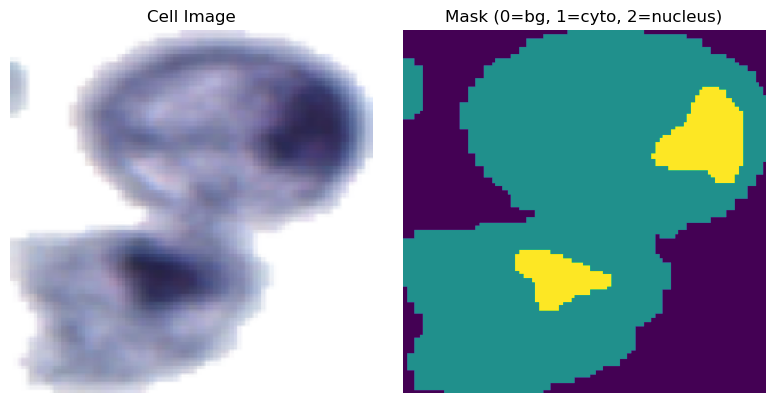

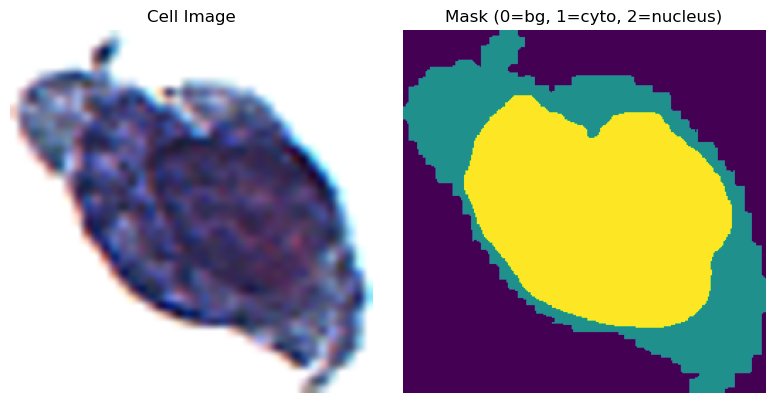

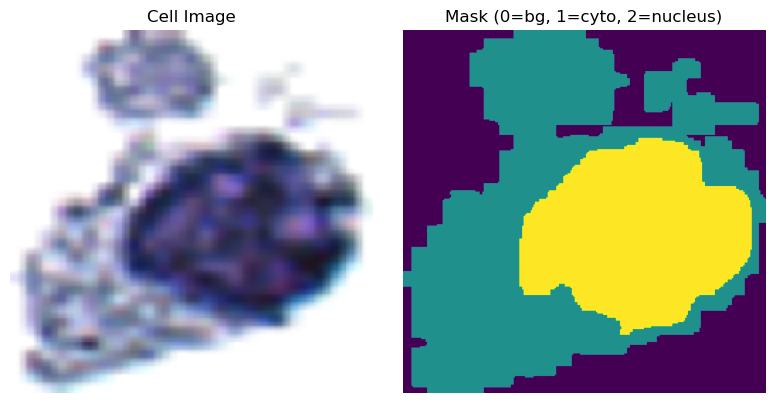

In [17]:
for i in range(3):
    show_image_mask(X[i], y[i])

# Data Augmentation

#### Since the given date is only 200 images I will expand it by rotating anf fliping the images

Generate 8 versions of an image/mask pair using rotations and flips.

Image shape: (C, H, W) — channels first
    
Mask shape:  (H, W)
    
Returns: list of (image, mask) tuples

In [18]:
def augment_image_mask(image, mask):

    augmented = []

    transforms = [
        lambda img, m: (img, m),                                                      # 1. Original
        lambda img, m: (img[:, :, ::-1], m[:, ::-1]),                                # 2. Flip horizontal
        lambda img, m: (img[:, ::-1, :], m[::-1, :]),                                # 3. Flip vertical
        lambda img, m: (np.rot90(img, k=1, axes=(1,2)), np.rot90(m, k=1)),           # 4. Rotate 90°
        lambda img, m: (np.rot90(img, k=2, axes=(1,2)), np.rot90(m, k=2)),           # 5. Rotate 180°
        lambda img, m: (np.rot90(img, k=3, axes=(1,2)), np.rot90(m, k=3)),           # 6. Rotate 270°
        lambda img, m: (np.rot90(img[:, :, ::-1], k=1, axes=(1,2)),                  # 7. Rotate 90° + flip H
                        np.rot90(m[:, ::-1], k=1)),
        lambda img, m: (np.rot90(img[:, :, ::-1], k=3, axes=(1,2)),                  # 8. Rotate 270° + flip H
                        np.rot90(m[:, ::-1], k=3)),
    ]

    for t in transforms:
        img_aug, mask_aug = t(image, mask)
        augmented.append((np.ascontiguousarray(img_aug), np.ascontiguousarray(mask_aug)))

    return augmented

In [19]:
X_aug, y_aug = [], []

for img, mask in zip(X, y):
    for img_t, mask_t in augment_image_mask(img, mask):
        X_aug.append(img_t)
        y_aug.append(mask_t)

X_aug = np.array(X_aug)  # shape: (1600, 3, 256, 256)
y_aug = np.array(y_aug)  # shape: (1600, 256, 256)

print(f"Augmented dataset: {X_aug.shape}, {y_aug.shape}")

Augmented dataset: (1528, 3, 256, 256), (1528, 256, 256)


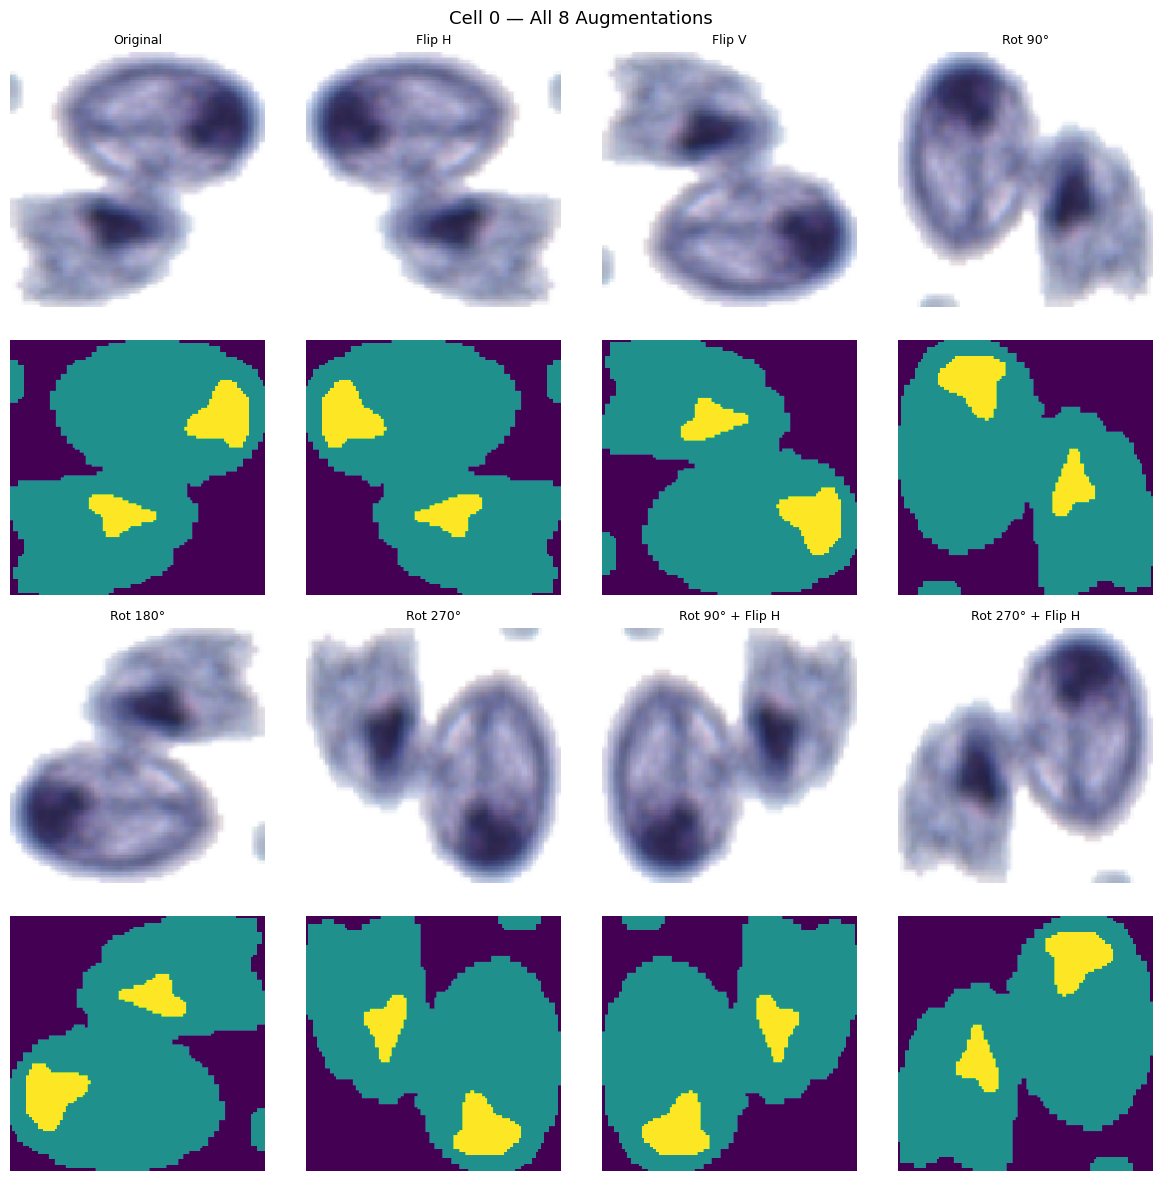

In [20]:
fig, axes = plt.subplots(4, 4, figsize=(12, 12))

labels = [
    'Original', 'Flip H', 'Flip V', 'Rot 90°',
    'Rot 180°', 'Rot 270°', 'Rot 90° + Flip H', 'Rot 270° + Flip H'
]

for i, (img, mask) in enumerate(versions):
    img_plot = img.transpose(1, 2, 0)
    
    col = i % 4          # 0,1,2,3 then 0,1,2,3
    img_row = (i // 4) * 2      # 0 for first 4, 2 for last 4
    mask_row = img_row + 1      # 1 for first 4, 3 for last 4
    
    axes[img_row, col].imshow(img_plot)
    axes[img_row, col].set_title(labels[i], fontsize=9)
    axes[img_row, col].axis('off')
    
    axes[mask_row, col].imshow(mask, cmap='viridis', vmin=0, vmax=2)
    axes[mask_row, col].axis('off')

plt.suptitle('Cell 0 — All 8 Augmentations', fontsize=13)
plt.tight_layout()
plt.show()

# U-NET

In [23]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

In [24]:
class CellDataset(Dataset):
    def __init__(self, X_aug, y_aug):
        self.X = torch.tensor(X_aug, dtype=torch.float32)
        self.y = torch.tensor(y_aug, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [25]:
split = int(0.8 * len(X_aug))
train_dataset = CellDataset(X_aug[:split], y_aug[:split])
test_dataset  = CellDataset(X_aug[split:], y_aug[split:])

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=8, shuffle=False)

print(f"Train: {len(train_dataset)} | Test: {len(test_dataset)}")

Train: 1222 | Test: 306


In [26]:
def conv_block(in_ch, out_ch):
    return nn.Sequential(
        nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
        nn.ReLU(inplace=True),
        nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1),
        nn.ReLU(inplace=True)
    )

class UNet(nn.Module):
    def __init__(self, in_channels=3, num_classes=3):
        super().__init__()

        # Encoder
        self.enc1 = conv_block(in_channels, 64)
        self.enc2 = conv_block(64, 128)
        self.enc3 = conv_block(128, 256)
        self.enc4 = conv_block(256, 512)
        self.pool = nn.MaxPool2d(2)

        # Bottleneck
        self.bottleneck = conv_block(512, 1024)

        # Decoder
        self.up4   = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2)
        self.dec4  = conv_block(1024, 512)
        self.up3   = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.dec3  = conv_block(512, 256)
        self.up2   = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.dec2  = conv_block(256, 128)
        self.up1   = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec1  = conv_block(128, 64)

        # Output
        self.out = nn.Conv2d(64, num_classes, kernel_size=1)

    def forward(self, x):
        # Encoder
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))

        # Bottleneck
        b = self.bottleneck(self.pool(e4))

        # Decoder
        d4 = self.dec4(torch.cat([self.up4(b),  e4], dim=1))
        d3 = self.dec3(torch.cat([self.up3(d4), e3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))

        return self.out(d1)

In [27]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using: {device}")

model     = UNet(in_channels=3, num_classes=3).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

Using: cpu


In [28]:
EPOCHS = 20

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0

    for images, masks in train_loader:
        images, masks = images.to(device), masks.to(device)

        optimizer.zero_grad()
        output = model(images)
        loss   = criterion(output, masks)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}/{EPOCHS} — Loss: {total_loss/len(train_loader):.4f}")

Epoch 1/20 — Loss: 0.6510
Epoch 2/20 — Loss: 0.3189
Epoch 3/20 — Loss: 0.3064
Epoch 4/20 — Loss: 0.2917
Epoch 5/20 — Loss: 0.2941
Epoch 6/20 — Loss: 0.2826
Epoch 7/20 — Loss: 0.2769
Epoch 8/20 — Loss: 0.2705
Epoch 9/20 — Loss: 0.2677
Epoch 10/20 — Loss: 0.2827
Epoch 11/20 — Loss: 0.2755
Epoch 12/20 — Loss: 0.2477
Epoch 13/20 — Loss: 0.2397
Epoch 14/20 — Loss: 0.2249
Epoch 15/20 — Loss: 0.2259
Epoch 16/20 — Loss: 0.2166
Epoch 17/20 — Loss: 0.2035
Epoch 18/20 — Loss: 0.1990
Epoch 19/20 — Loss: 0.2654
Epoch 20/20 — Loss: 0.2085


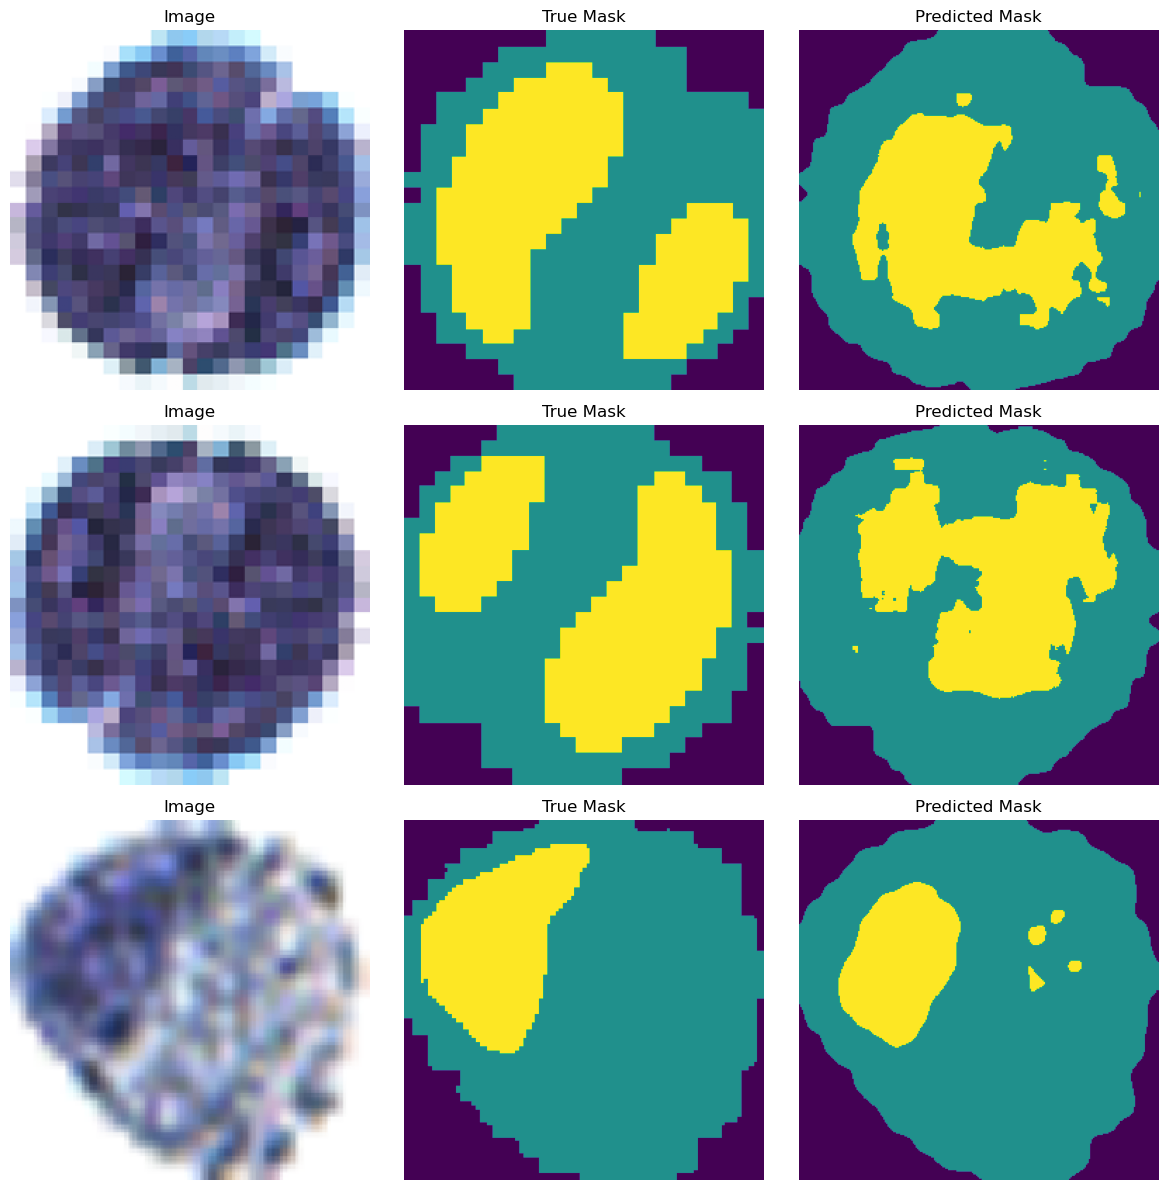

In [36]:
model.eval()
with torch.no_grad():
    images, masks = next(iter(test_loader))
    images = images.to(device)
    output = model(images)
    predicted = output.argmax(dim=1).cpu().numpy()

fig, axes = plt.subplots(3, 3, figsize=(12, 12))
for i in range(3):
    axes[i, 0].imshow(images[i].cpu().numpy().transpose(1, 2, 0))
    axes[i, 0].set_title('Image')
    axes[i, 0].axis('off')

    axes[i, 1].imshow(masks[i].numpy(), cmap='viridis', vmin=0, vmax=2)
    axes[i, 1].set_title('True Mask')
    axes[i, 1].axis('off')

    axes[i, 2].imshow(predicted[i], cmap='viridis', vmin=0, vmax=2)
    axes[i, 2].set_title('Predicted Mask')
    axes[i, 2].axis('off')
    

plt.tight_layout()
plt.show()

In [31]:
def dice_score(predicted_mask, true_mask, label=2):
    pred = (predicted_mask == label)
    true = (true_mask == label)
    
    intersection = (pred & true).sum()
    total = pred.sum() + true.sum()
    
    if total == 0:
        return 1.0
    return 2 * intersection / total

def iou_score(predicted_mask, true_mask, label=2):
    pred = (predicted_mask == label)
    true = (true_mask == label)
    
    intersection = (pred & true).sum()
    union = (pred | true).sum()
    
    if union == 0:
        return 1.0
    return intersection / union

In [32]:
dice_scores = []
iou_scores  = []

model.eval()
with torch.no_grad():
    for images, masks in test_loader:
        images = images.to(device)
        output = model(images)
        predicted = output.argmax(dim=1).cpu().numpy()

        for pred, true in zip(predicted, masks.numpy()):
            dice_scores.append(dice_score(pred, true))
            iou_scores.append(iou_score(pred, true))

print(f"Mean Dice Score : {np.mean(dice_scores):.4f}")
print(f"Mean IoU Score  : {np.mean(iou_scores):.4f}")

Mean Dice Score : 0.7541
Mean IoU Score  : 0.6373
